# 05 — Backtest: RandomTrader (engine correctness check)

Expected: negative net P&L of roughly -total_fees over many random trades.

In [1]:
# Notebook is location-agnostic: walk up to find the project root
# (the dir containing pyproject.toml) and chdir there before any imports.
import os, pathlib
_p = pathlib.Path.cwd()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
if (_p / "pyproject.toml").exists():
    os.chdir(_p)
del _p


In [2]:
from datetime import datetime, timezone
from src.layer1_research.backtesting.config import BacktestConfig
from src.layer1_research.backtesting.runner import BacktestRunner
from src.layer1_research.backtesting.strategies.examples.random_trader import (
    RandomTraderStrategy,
)
from src.layer1_research.backtesting.reporting.cli_report import print_report

In [3]:
config = BacktestConfig(
    catalog_path="data/catalog",
    start=datetime(2024, 6, 1, tzinfo=timezone.utc),
    end=datetime(2024, 9, 1, tzinfo=timezone.utc),
    strategy_name="random_trader",
    starting_capital=10_000.0,
    data_mode="trade",
    fee_rate_bps=100,
    strategy_params={"seed": 42, "p_trade": 0.02, "trade_size": 5.0},
)

In [4]:
result = BacktestRunner(config).run(RandomTraderStrategy)
print_report(result.metrics())

2024-08-31T23:59:49.000000000Z [WARN] BACKTESTER-001.RandomTraderStrategy: The `Strategy.on_stop` handler was called when not overridden. It's expected that any actions required when stopping the strategy occur here, such as unsubscribing from data



  Backtest results
  Total Return:                0.68%
  Sharpe Ratio:                0.56
  Sortino Ratio:               1.32
  Max Drawdown:                2.10%
  Calmar Ratio:                0.32
  Total Trades:                4838
  Win Rate:                   20.7%
  Avg Win:             $       0.06
  Avg Loss:            $      -0.09
  Profit Factor:               0.18
  Avg Hold Time:       19 days 23:12:30.197722567
  Total Fees:          $     229.05
  Fee Drag:                   77.2%
  Avg Slippage:            2893.5 bps
  Avg Edge @ Order:         -0.0004
  Edge Realization:            0.01
  Top 5 markets by P&L:
    8793579883083155552129923223812193456097 $       -1  (487 trades, win 37%)
    8758495535924524640495212808245189728777 $       -5  (325 trades, win 39%)
    4389801918844310925454401164414109574832 $      -14  (70 trades, win 20%)
    2127100029184336124920906570609716702908 $      -24  (337 trades, win 16%)
    5767780449058588739870602419398752995509 $ 

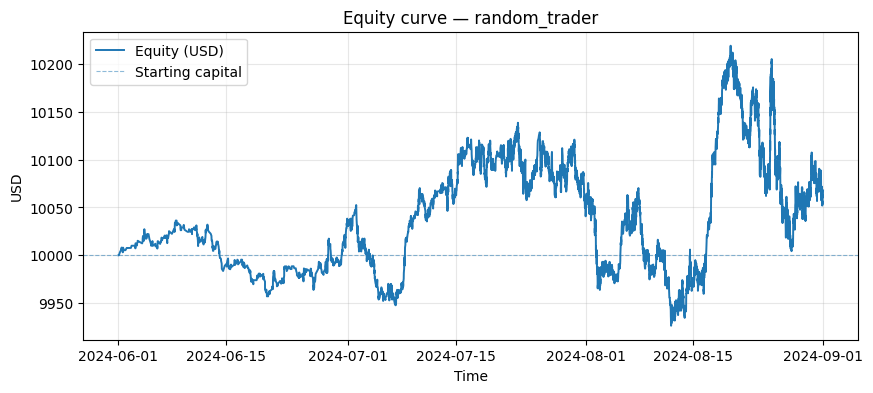

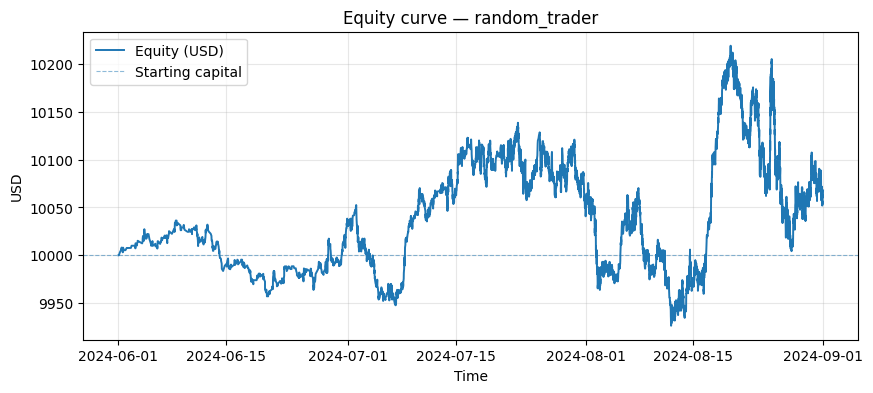

In [5]:
result.plot_equity_curve()

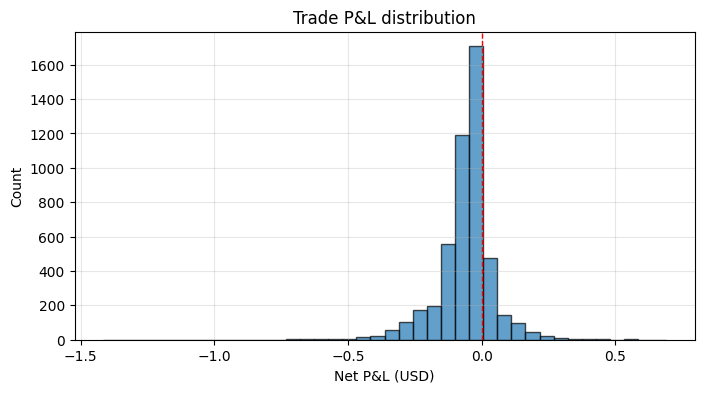

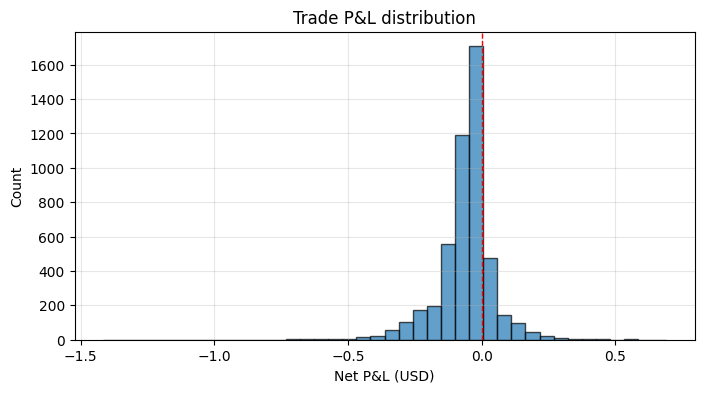

In [6]:
result.plot_pnl_histogram()

### Sanity check: final P&L should be roughly -total_fees

In [7]:
net_pnl = float(result.equity_curve.iloc[-1]) - config.starting_capital
fees = result.metrics().total_fees
print(f"Net P&L:    ${net_pnl:,.2f}")
print(f"Total fees: ${fees:,.2f}")
if fees > 0:
    print(f"Ratio:      {net_pnl / -fees:.2f}   (ideal: ~1.0)")

Net P&L:    $67.82
Total fees: $229.05
Ratio:      -0.30   (ideal: ~1.0)
